# DeepFashion Product Captioning with BLIP-2

Generates natural language descriptions for all cropped product images
using the frozen **BLIP-2** vision-language model.

---

### Role of BLIP-2 in the pipeline

BLIP-2 reads a cropped clothing image and produces a description such as:
> *'a woman wearing a floral midi dress with short sleeves'*

These descriptions feed into the CLIP fusion step:
```
embedding = alpha * CLIP_vision(crop) + (1 - alpha) * CLIP_text(description)
```
Blending visual and textual signals improves retrieval quality
compared to image-only embeddings.

---

### BLIP-2 is used as-is — no weight updates
The project specification states BLIP-2 remains frozen throughout.
We only perform forward passes for caption generation.

---

### Generation settings chosen for speed
| Parameter | Value | Reason |
|-----------|-------|--------|
| `num_beams` | 1 (greedy) | Roughly 4× faster than beam search |
| `imgs_per_batch` | 16 | Saturates T4 GPU memory efficiently |
| `max_new_tokens` | 30 | Concise descriptions generate faster |

Full run (~38 k images) completes in approximately 2.5 hours.

---

### Required input datasets
- `yolo-bbox-crops-v1` — ground-truth bbox crops and `master_crops.csv`

### Files produced
- `all_captions.json` — combined gallery + train descriptions
- `gallery_captions.json` — gallery split only
- `train_captions.json` — train split only

## 1. Install Dependencies

In [1]:
!pip install transformers accelerate bitsandbytes Pillow --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.6 MB/s eta 0:00:00


## 2. Import Libraries

In [2]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from transformers import Blip2Processor, Blip2ForConditionalGeneration, BitsAndBytesConfig

warnings.filterwarnings('ignore')

COMPUTE_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Compute device  : {COMPUTE_DEVICE}')
print(f'PyTorch version : {torch.__version__}')
print('Imports complete!')

Compute device  : cuda
PyTorch version : 2.10.0+cu128
Imports complete!


## 3. Settings

Set `TARGET_SPLITS` to control which images get captioned:
- `'all'` → gallery + train in one run (~2.5 hrs, recommended)
- `'gallery'` → gallery images only (~50–60 min)
- `'train'` → train images only (~90–100 min)

In [3]:
# ── Change this to select which splits to process ─────────────────────────────
TARGET_SPLITS = 'all'   # choices: 'all'  |  'gallery'  |  'train'
# ─────────────────────────────────────────────────────────────────────────────

# Dataset containing bbox crops and the master CSV
CROPS_INPUT_DIR = '/kaggle/input/datasets/akibatra25/vr-yolo-bbox-cropped-images'

# Where outputs will be written
SAVE_DIR = '/kaggle/working'
os.makedirs(SAVE_DIR, exist_ok=True)

# Generation hyperparameters
IMGS_PER_BATCH   = 16
MAX_NEW_TOKENS   = 30
DECODE_BEAMS     = 1      # 1 = greedy decoding, fastest option
SAVE_INTERVAL    = 500    # write checkpoint to disk every N captions

found = 'Found' if os.path.exists(CROPS_INPUT_DIR) else 'NOT FOUND'
print(f'[{found}] CROPS_INPUT_DIR: {CROPS_INPUT_DIR}')
print(f'\nSettings:')
print(f'  TARGET_SPLITS  : {TARGET_SPLITS}')
print(f'  IMGS_PER_BATCH : {IMGS_PER_BATCH}')
print(f'  MAX_NEW_TOKENS : {MAX_NEW_TOKENS}')
print(f'  DECODE_BEAMS   : {DECODE_BEAMS}  (greedy)')

if os.path.exists(CROPS_INPUT_DIR):
    print('\nDataset contents:')
    for entry in sorted(os.listdir(CROPS_INPUT_DIR))[:15]:
        print(f'  {entry}')

[Found] CROPS_INPUT_DIR: /kaggle/input/datasets/akibatra25/vr-yolo-bbox-cropped-images

Settings:
  TARGET_SPLITS  : all
  IMGS_PER_BATCH : 16
  MAX_NEW_TOKENS : 30
  DECODE_BEAMS   : 1  (greedy)

Dataset contents:
  data
  gallery_crops.csv
  master_crops.csv
  query_crops.csv
  train_crops.csv


## 4. Load CSV and Fix Crop Paths

`master_crops.csv` stores paths as `/kaggle/working/data/bbox_crops/...`
(where they were written during cropping). Since the crops now live inside
a Kaggle input dataset, we translate those paths before reading any files.

In [4]:
master_path = os.path.join(CROPS_INPUT_DIR, 'master_crops.csv')
records = pd.read_csv(master_path)

print(f'Rows in master_crops.csv : {len(records):,}')
print(f'Columns                  : {records.columns.tolist()}')
print()
print('Images per split:')
print(records['split'].value_counts().to_string())

def fix_path(stored_path):
    """
    Translate a path written as /kaggle/working/data/bbox_crops/...
    to the correct location inside the input dataset.
    """
    if pd.isna(stored_path):
        return stored_path
    tail = stored_path.replace('/kaggle/working/', '')
    return os.path.join(CROPS_INPUT_DIR, tail)

records['resolved_path'] = records['crop_path'].apply(fix_path)
records['file_found']    = records['resolved_path'].apply(
    lambda p: os.path.exists(p) if isinstance(p, str) else False
)

print('\nSample resolved paths:')
for p in records['resolved_path'].head(3):
    tag = 'OK' if os.path.exists(p) else 'MISSING'
    print(f'  [{tag}] {p}')

print(f'\nFiles accessible on disk: {records["file_found"].sum():,} / {len(records):,}')

Rows in master_crops.csv : 52,712
Columns                  : ['image_name', 'item_id', 'split', 'clothes_type', 'pose_type', 'x1', 'y1', 'x2', 'y2', 'crop_path', 'crop_exists', 'crop_method']

Images per split:
split
train      25882
query      14218
gallery    12612

Sample resolved paths:
  [OK] /kaggle/input/datasets/akibatra25/vr-yolo-bbox-cropped-images/data/bbox_crops/WOMEN/Dresses/id_00000002/02_1_front.jpg
  [OK] /kaggle/input/datasets/akibatra25/vr-yolo-bbox-cropped-images/data/bbox_crops/WOMEN/Dresses/id_00000002/02_2_side.jpg
  [OK] /kaggle/input/datasets/akibatra25/vr-yolo-bbox-cropped-images/data/bbox_crops/WOMEN/Dresses/id_00000002/02_4_full.jpg

Files accessible on disk: 52,712 / 52,712


## 5. Select Images to Process

In [5]:
if TARGET_SPLITS == 'all':
    active_splits = ['gallery', 'train']
elif TARGET_SPLITS == 'gallery':
    active_splits = ['gallery']
elif TARGET_SPLITS == 'train':
    active_splits = ['train']
else:
    raise ValueError(f'Unrecognised TARGET_SPLITS value: {TARGET_SPLITS}')

work_df = records[
    (records['split'].isin(active_splits)) &
    (records['file_found'] == True)
].reset_index(drop=True)

gallery_records = records[(records['split'] == 'gallery') & (records['file_found'])].reset_index(drop=True)
train_records   = records[(records['split'] == 'train')   & (records['file_found'])].reset_index(drop=True)

print(f'TARGET_SPLITS        : {TARGET_SPLITS}')
print(f'Gallery rows ready   : {len(gallery_records):,}')
print(f'Train rows ready     : {len(train_records):,}')
print(f'Images to process    : {len(work_df):,}')

TARGET_SPLITS        : all
Gallery rows ready   : 12,612
Train rows ready     : 25,882
Images to process    : 38,494


## 6. Load BLIP-2 (Frozen, 8-bit)

`Salesforce/blip2-opt-2.7b` is loaded with 8-bit quantisation
to keep GPU memory within T4 limits.
All weights are frozen — zero trainable parameters.
Internet must be enabled on first run (~6 GB download).

In [6]:
BLIP2_REPO = 'Salesforce/blip2-opt-2.7b'

print(f'Loading BLIP-2 checkpoint: {BLIP2_REPO}')
print('Downloading weights on first run (~6 GB) — please wait...')

blip_processor = Blip2Processor.from_pretrained(BLIP2_REPO, use_fast=False)

quant_cfg = BitsAndBytesConfig(
    load_in_8bit=True,
    bnb_8bit_compute_dtype=torch.float16
)

blip_model = Blip2ForConditionalGeneration.from_pretrained(
    BLIP2_REPO,
    quantization_config=quant_cfg,
    device_map='auto',
    torch_dtype=torch.float16
)

# Freeze every parameter — BLIP-2 is inference-only
for param in blip_model.parameters():
    param.requires_grad = False
blip_model.eval()

print('BLIP-2 ready!')
n_trainable = sum(p.numel() for p in blip_model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_trainable:,}  (should be 0)')

Loading BLIP-2 checkpoint: Salesforce/blip2-opt-2.7b


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

BLIP-2 ready!
Trainable parameters: 0  (should be 0)


## 7. Preview Captions on Random Samples

Run on a handful of images before the full loop to confirm
the model is working and the crops look reasonable.

The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.


Image       : 01_2_side.jpg
Description : a woman in a colorful dress is looking at a camera



The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.


Image       : 04_2_side.jpg
Description : a woman in jeans and a white top



The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.


Image       : 02_7_additional.jpg
Description : a woman wearing a pair of shorts with a high waist

Image       : 01_2_side.jpg
Description : a woman in a black shirt and shorts



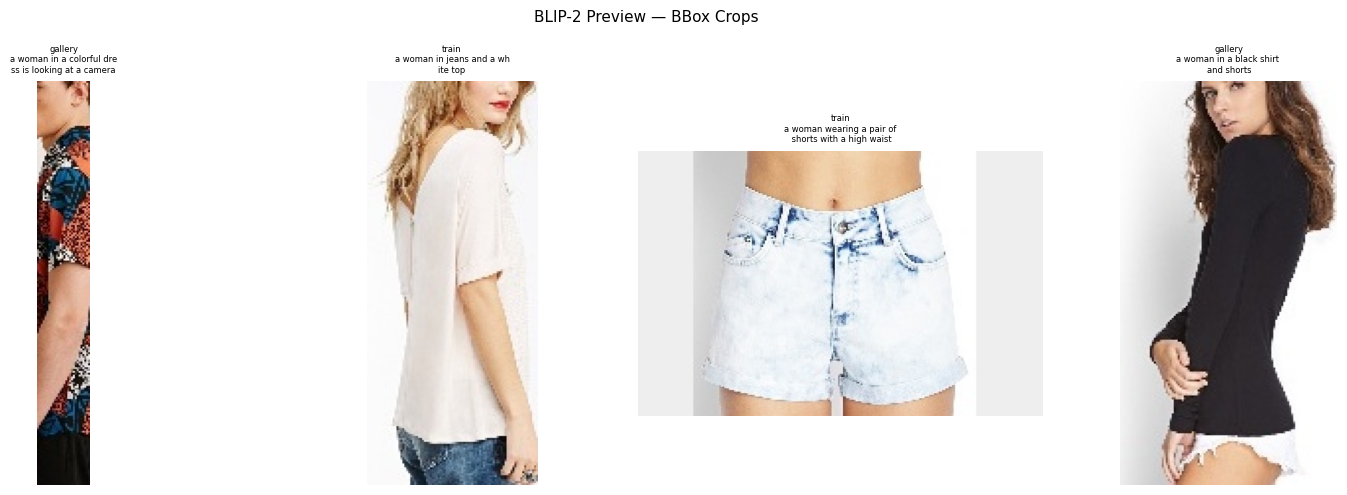

In [7]:
preview_rows = work_df.sample(4, random_state=42)

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, (_, row) in enumerate(preview_rows.iterrows()):
    try:
        img = Image.open(row['resolved_path']).convert('RGB')
        inputs = blip_processor(images=img, return_tensors='pt').to(COMPUTE_DEVICE, torch.float16)
        with torch.no_grad():
            token_ids = blip_model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                num_beams=DECODE_BEAMS
            )
        description = blip_processor.decode(token_ids[0], skip_special_tokens=True).strip()

        axes[i].imshow(img)
        wrapped = '\n'.join([description[j:j+25] for j in range(0, len(description), 25)])
        axes[i].set_title(f'{row["split"]}\n{wrapped}', fontsize=6)
        axes[i].axis('off')

        print(f'Image       : {row["image_name"].split("/")[-1]}')
        print(f'Description : {description}')
        print()
    except Exception as exc:
        print(f'Preview error (sample {i}): {exc}')
        axes[i].axis('off')

plt.suptitle('BLIP-2 Preview — BBox Crops', fontsize=11)
plt.tight_layout()
plt.show()

## 8. Generate Captions for All Selected Images

Images are processed in batches of `IMGS_PER_BATCH`.
A checkpoint is written every `SAVE_INTERVAL` captions so progress
is never lost if the session disconnects.
Re-running the cell safely skips already-captioned images.

In [8]:
OUTPUT_JSON = os.path.join(SAVE_DIR, 'all_captions.json')

# Resume from checkpoint if one exists
if os.path.exists(OUTPUT_JSON):
    with open(OUTPUT_JSON, 'r') as fh:
        caption_store = json.load(fh)
    print(f'Checkpoint found — resuming from {len(caption_store):,} captions')
else:
    caption_store = {}
    print('No checkpoint found — starting fresh')

# Skip images already in the store
pending = work_df[
    ~work_df['image_name'].isin(caption_store.keys())
].reset_index(drop=True)

print(f'Already done : {len(caption_store):,}')
print(f'Remaining    : {len(pending):,}')
print()

error_log = []

for start in tqdm(range(0, len(pending), IMGS_PER_BATCH), desc='Captioning'):
    chunk = pending.iloc[start : start + IMGS_PER_BATCH]

    pil_imgs, img_keys = [], []
    for _, entry in chunk.iterrows():
        try:
            pil_imgs.append(Image.open(entry['resolved_path']).convert('RGB'))
            img_keys.append(entry['image_name'])
        except Exception:
            error_log.append(entry['image_name'])

    if not pil_imgs:
        continue

    try:
        batch_inputs = blip_processor(
            images=pil_imgs, return_tensors='pt', padding=True
        ).to(COMPUTE_DEVICE, torch.float16)

        with torch.no_grad():
            output_ids = blip_model.generate(
                **batch_inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                num_beams=DECODE_BEAMS
            )

        for idx, token_seq in enumerate(output_ids):
            text = blip_processor.decode(token_seq, skip_special_tokens=True).strip()
            caption_store[img_keys[idx]] = text

    except Exception:
        # Batch failed — fall back to single-image mode
        for pil_img, key in zip(pil_imgs, img_keys):
            try:
                single_in = blip_processor(
                    images=pil_img, return_tensors='pt'
                ).to(COMPUTE_DEVICE, torch.float16)
                with torch.no_grad():
                    out = blip_model.generate(**single_in, max_new_tokens=MAX_NEW_TOKENS)
                text = blip_processor.decode(out[0], skip_special_tokens=True).strip()
                caption_store[key] = text
            except Exception:
                error_log.append(key)

    # Periodic checkpoint save
    if len(caption_store) % SAVE_INTERVAL < IMGS_PER_BATCH:
        with open(OUTPUT_JSON, 'w') as fh:
            json.dump(caption_store, fh)
        print(f'  Checkpoint: {len(caption_store):,} captions saved')

# Final save
with open(OUTPUT_JSON, 'w') as fh:
    json.dump(caption_store, fh)

print(f'\nFinished!')
print(f'Total captions : {len(caption_store):,}')
print(f'Errors         : {len(error_log):,}')

No checkpoint found — starting fresh
Already done : 0
Remaining    : 38,494



Captioning:   1%|▏         | 32/2406 [01:50<2:18:50,  3.51s/it]The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.


  Checkpoint: 512 captions saved


Captioning:   3%|▎         | 63/2406 [03:40<2:16:45,  3.50s/it]The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.


  Checkpoint: 1,008 captions saved


...

  Checkpoint: 37,504 captions saved


Captioning:  99%|█████████▊| 2375/2406 [2:18:34<02:01,  3.93s/it]The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.


  Checkpoint: 38,000 captions saved


Captioning: 100%|██████████| 2406/2406 [2:20:17<00:00,  3.50s/it]


Finished!
Total captions : 38,494
Errors         : 0


## 9. Split and Save Per-Split Caption Files

In [9]:
gallery_keys = set(gallery_records['image_name'].tolist())
train_keys   = set(train_records['image_name'].tolist())

gallery_desc = {k: v for k, v in caption_store.items() if k in gallery_keys}
train_desc   = {k: v for k, v in caption_store.items() if k in train_keys}

with open(os.path.join(SAVE_DIR, 'gallery_captions.json'), 'w') as fh:
    json.dump(gallery_desc, fh)

with open(os.path.join(SAVE_DIR, 'train_captions.json'), 'w') as fh:
    json.dump(train_desc, fh)

print(f'all_captions.json     : {len(caption_store):,} entries')
print(f'gallery_captions.json : {len(gallery_desc):,} entries')
print(f'train_captions.json   : {len(train_desc):,} entries')

all_captions.json     : 38,494 entries
gallery_captions.json : 12,612 entries
train_captions.json   : 25,882 entries


## 10. Caption Quality Check

Visually inspect a grid of crops and their generated descriptions.

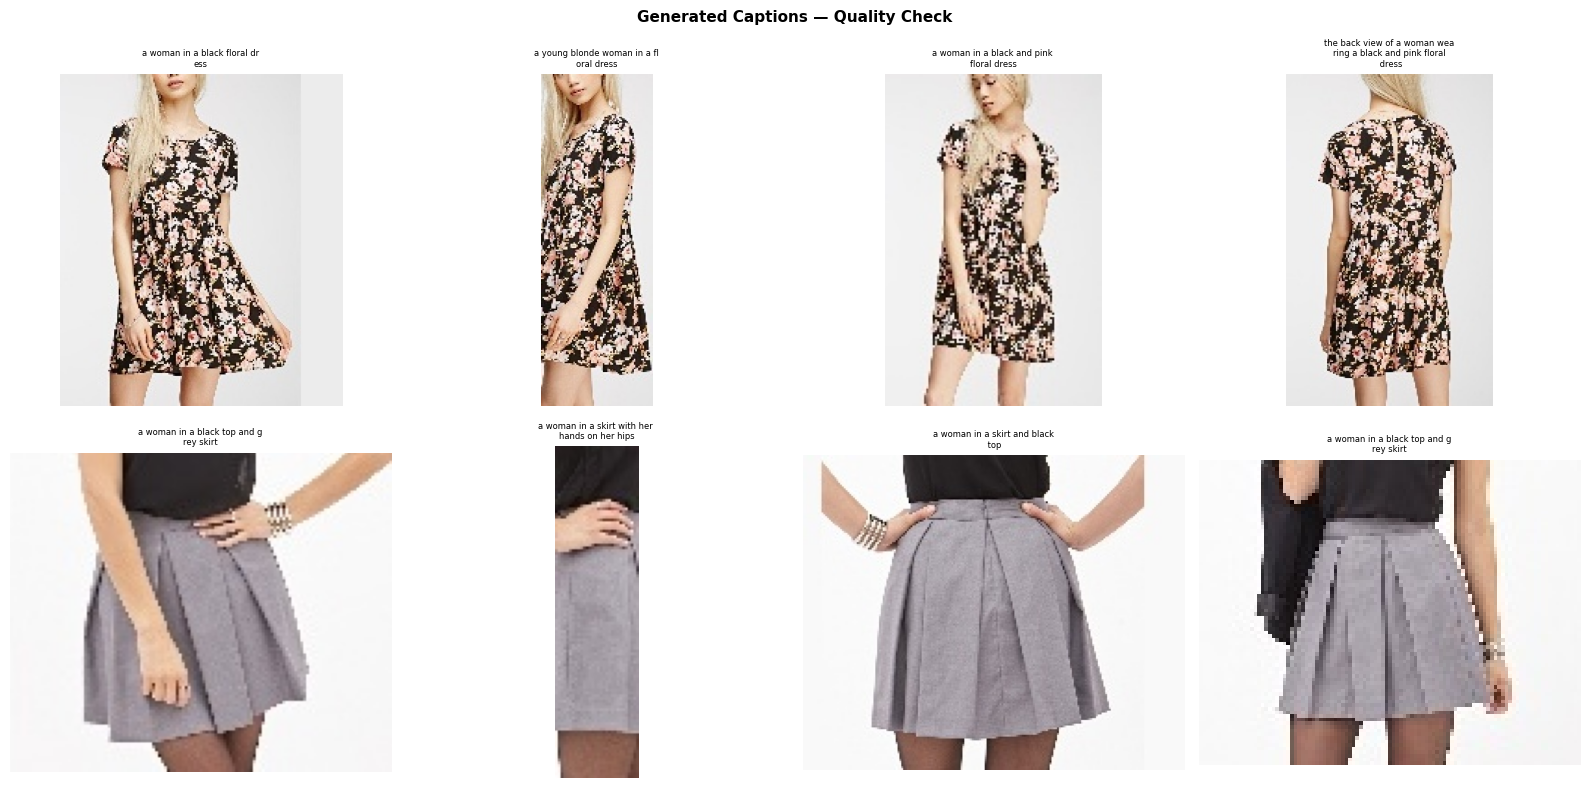

Word count — mean: 9.7  min: 2  max: 30

First 5 captions:
  02_1_front.jpg: a woman in a black floral dress
  02_2_side.jpg: a young blonde woman in a floral dress
  02_4_full.jpg: a woman in a black and pink floral dress
  02_7_additional.jpg: the back view of a woman wearing a black and pink floral dress
  02_1_front.jpg: a woman in a black top and grey skirt


In [10]:
display_keys = list(caption_store.keys())[:8]
display_rows = work_df[work_df['image_name'].isin(display_keys)].head(8)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (_, row) in enumerate(display_rows.iterrows()):
    if i >= 8:
        break
    try:
        img  = Image.open(row['resolved_path']).convert('RGB')
        desc = caption_store.get(row['image_name'], 'no description')
        axes[i].imshow(img)
        wrapped = '\n'.join([desc[j:j+28] for j in range(0, min(len(desc), 84), 28)])
        axes[i].set_title(wrapped, fontsize=6)
        axes[i].axis('off')
    except Exception:
        axes[i].axis('off')

for j in range(i + 1, 8):
    axes[j].axis('off')

plt.suptitle('Generated Captions — Quality Check', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

word_counts = [len(d.split()) for d in caption_store.values()]
print(f'Word count — mean: {np.mean(word_counts):.1f}  '
      f'min: {np.min(word_counts)}  max: {np.max(word_counts)}')

print('\nFirst 5 captions:')
for key, desc in list(caption_store.items())[:5]:
    print(f'  {key.split("/")[-1]}: {desc}')

## 11. Coverage Report

In [11]:
print('=== Caption Coverage ===')
print(f'Gallery : {len(gallery_desc):,} / {len(gallery_records):,}  '
      f'({len(gallery_desc)/len(gallery_records)*100:.1f}%)')
print(f'Train   : {len(train_desc):,} / {len(train_records):,}  '
      f'({len(train_desc)/len(train_records)*100:.1f}%)')

missing_g = gallery_records[~gallery_records['image_name'].isin(gallery_desc.keys())]
missing_t = train_records[~train_records['image_name'].isin(train_desc.keys())]
print(f'\nUncaptioned gallery : {len(missing_g):,}')
print(f'Uncaptioned train   : {len(missing_t):,}')

=== Caption Coverage ===
Gallery : 12,612 / 12,612  (100.0%)
Train   : 25,882 / 25,882  (100.0%)

Uncaptioned gallery : 0
Uncaptioned train   : 0


## 12. Summary

In [12]:
print('=' * 57)
print('        BLIP-2 CAPTIONING — COMPLETE')
print('=' * 57)
print(f'  Checkpoint        : {BLIP2_REPO}')
print(f'  Training done     : No — inference only')
print(f'  Crop source       : Ground truth annotation bbox')
print(f'  Total captions    : {len(caption_store):,}')
print(f'  Gallery captions  : {len(gallery_desc):,}')
print(f'  Train captions    : {len(train_desc):,}')
print(f'  Generation errors : {len(error_log):,}')
print()
print('  Save to new Kaggle dataset:')
print('    all_captions.json')
print('    gallery_captions.json')
print('    train_captions.json')
print()
print('  Next step: CLIP Embedding + FAISS Index (Configs A and B)')
print('=' * 57)

        BLIP-2 CAPTIONING — COMPLETE
  Checkpoint        : Salesforce/blip2-opt-2.7b
  Training done     : No — inference only
  Crop source       : Ground truth annotation bbox
  Total captions    : 38,494
  Gallery captions  : 12,612
  Train captions    : 25,882
  Generation errors : 0

  Save to new Kaggle dataset:
    all_captions.json
    gallery_captions.json
    train_captions.json

  Next step: CLIP Embedding + FAISS Index (Configs A and B)
